First 5 Rows:
         Ax        Ay        Az        Gx        Gy        Gz Posture
0 -2.275117  0.654630  9.189544  0.684225 -0.458413 -0.062074    LEFT
1 -1.860479  0.803155  8.767649 -0.262585 -0.285690 -0.462041    LEFT
2  0.524358  1.741376  8.074478 -0.081934 -0.738165  0.743490    BENT
3  1.727809  0.533277  8.539603  0.187849 -0.300319 -0.145847   RIGHT
4  2.389596  0.169671  9.452091  0.186559 -0.193236 -0.579385   RIGHT

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ax       600 non-null    float64
 1   Ay       600 non-null    float64
 2   Az       600 non-null    float64
 3   Gx       600 non-null    float64
 4   Gy       600 non-null    float64
 5   Gz       600 non-null    float64
 6   Posture  600 non-null    object 
dtypes: float64(6), object(1)
memory usage: 32.9+ KB
None

Missing Values:
Ax         0
Ay         0
Az  

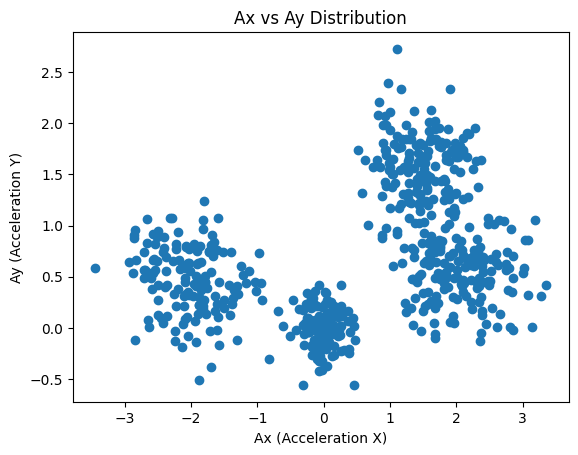


Model trained successfully!

Model Accuracy: 0.925


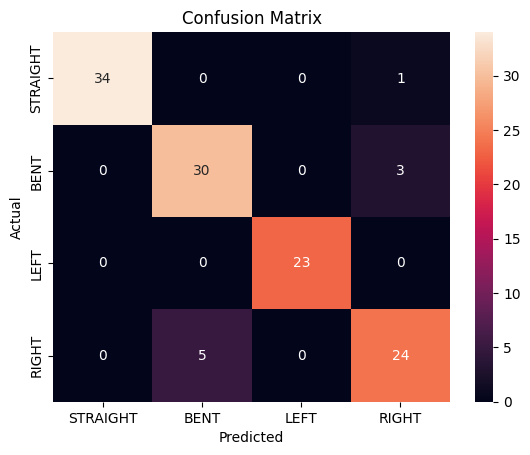

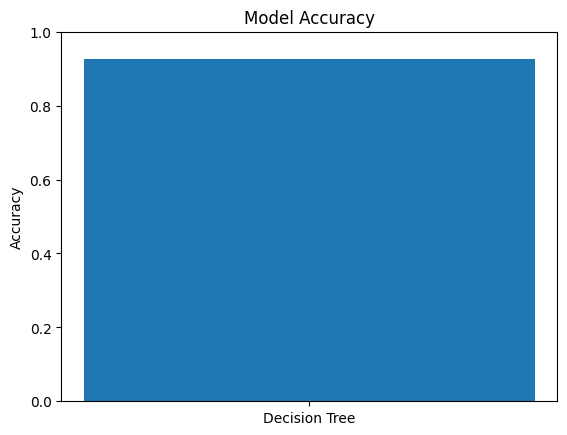


Predicted Posture: STRAIGHT


In [9]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ============================================
# 2. LOAD DATASET
# ============================================
data = pd.read_csv("mpu6050_dataset.csv")

print("First 5 Rows:")
print(data.head())

# ============================================
# 3. DATA INFORMATION & CLEANING
# ============================================
print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# ============================================
# 4. DATA PREPROCESSING (ENCODING LABELS)
# ============================================
data['Posture_encoded'] = data['Posture'].map({
    'STRAIGHT': 0,
    'BENT': 1,
    'LEFT': 2,
    'RIGHT': 3
})

print("\nEncoded Data Sample:")
print(data.head())

# ============================================
# 5. DATA VISUALIZATION
# ============================================
plt.figure()
plt.scatter(data['Ax'], data['Ay'])
plt.xlabel("Ax (Acceleration X)")
plt.ylabel("Ay (Acceleration Y)")
plt.title("Ax vs Ay Distribution")
plt.show()

# ============================================
# 6. PREPARE DATA FOR MACHINE LEARNING
# ============================================
from sklearn.model_selection import train_test_split

X = data[['Ax','Ay','Az','Gx','Gy','Gz']]   # Input features
y = data['Posture_encoded']                # Output label

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# ============================================
# 7. TRAIN MACHINE LEARNING MODEL
# ============================================
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("\nModel trained successfully!")

# ============================================
# 8. MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test)

# ============================================
# 9. MODEL ACCURACY
# ============================================
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# ============================================
# 10. CONFUSION MATRIX (GRAPH)
# ============================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['STRAIGHT','BENT','LEFT','RIGHT'],
            yticklabels=['STRAIGHT','BENT','LEFT','RIGHT'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ============================================
# 11. ACCURACY GRAPH
# ============================================
plt.figure()
plt.bar(["Decision Tree"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

# ============================================
# 12. TEST WITH NEW INPUT (SMART FEATURE)
# ============================================
sample = pd.DataFrame([[0.1, 0.2, 9.7, 0.1, 0.2, 0.1]],
                      columns=['Ax','Ay','Az','Gx','Gy','Gz'])

prediction = model.predict(sample)

map_label = {
    0: "STRAIGHT",
    1: "BENT",
    2: "LEFT",
    3: "RIGHT"
}

print("\nPredicted Posture:", map_label[prediction[0]])